In [2]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Update with your actual file path
data = pd.read_excel(data_path)

# Define the column names for text and target labels
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Convert text data to numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Feature matrix
y = data[target_column]  # Target labels

# Step 2: Split the dataset into training (80%) and testing (20%) sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the Random Forest model
print("Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 trees in the forest
rf_model.fit(X_train_tfidf, y_train)

# Step 4: Save the trained Random Forest model
model_path = r"C:\Users\PC\Downloads\RF_model.pkl"  # Update with your desired save path
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f"Trained Random Forest model saved to {model_path}")

# Step 5: Evaluate the Random Forest model
y_pred_rf = rf_model.predict(X_test_tfidf)

# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred_rf) * 100
precision = precision_score(y_test, y_pred_rf, average='weighted') * 100  # Change to 'macro' for macro-average
recall = recall_score(y_test, y_pred_rf, average='weighted') * 100
f1 = f1_score(y_test, y_pred_rf, average='weighted') * 100

# Print evaluation metrics in percentage format
print(f"\nRandom Forest Evaluation Results:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))  # Ensures results are printed with high precision


Training Random Forest Model...
Trained Random Forest model saved to C:\Users\PC\Downloads\RF_model.pkl

Random Forest Evaluation Results:
Accuracy: 90.63%
Precision: 90.65%
Recall: 90.63%
F1 Score: 90.63%

Classification Report:
              precision    recall  f1-score   support

           0     0.9160    0.8949    0.9053     23238
           1     0.8970    0.9177    0.9072     23171

    accuracy                         0.9063     46409
   macro avg     0.9065    0.9063    0.9063     46409
weighted avg     0.9065    0.9063    0.9063     46409



Confusion Matrix:
[[20795  2443]
 [ 1907 21264]]


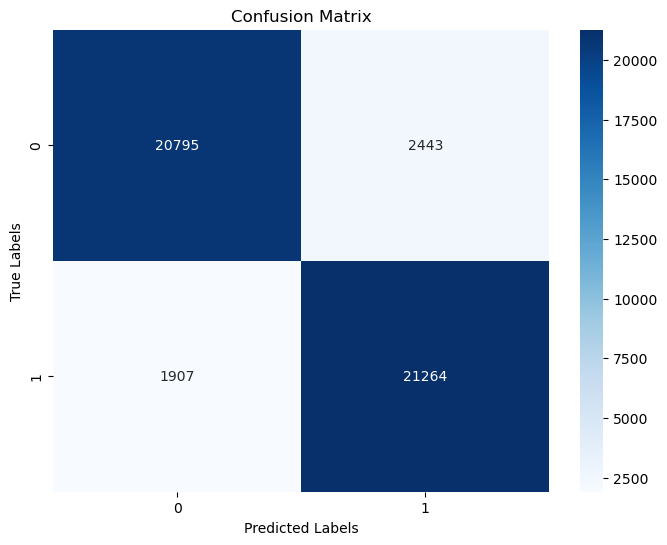

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 6: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


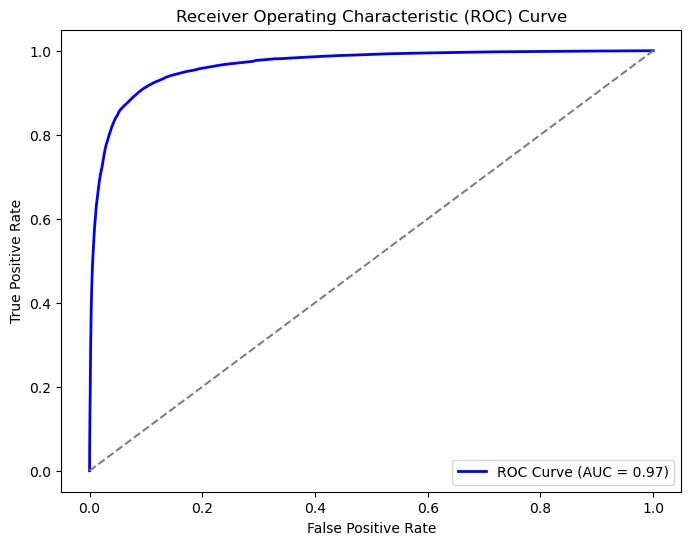

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC Curve
if len(rf_model.classes_) == 2:  # ROC curve is applicable for binary classification
    y_prob_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()


Training Random Forest model...
Random Forest MAE: 0.0937, MSE: 0.0937, RMSE: 0.3062


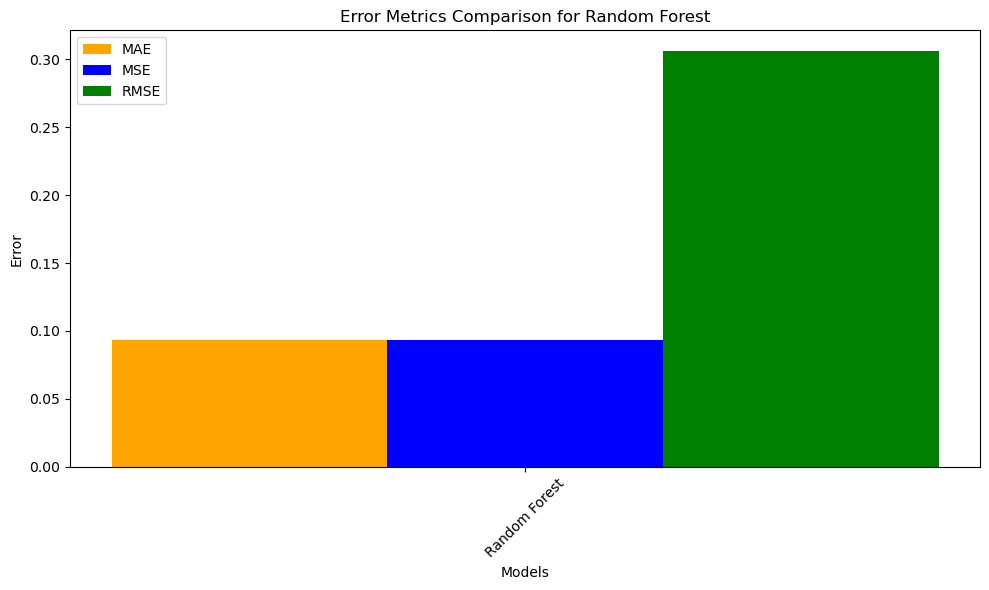

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Dictionary to store error metrics
error_metrics = {}

# Assuming you already have X_train_tfidf, X_test_tfidf, y_train, and y_test ready
# Initialize and train the Random Forest model
print("Training Random Forest model...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test_tfidf)

# Calculate error metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

# Store error metrics
error_metrics["Random Forest"] = {"MAE": mae_rf, "MSE": mse_rf, "RMSE": rmse_rf}

# Print metrics
print(f"Random Forest MAE: {mae_rf:.4f}, MSE: {mse_rf:.4f}, RMSE: {rmse_rf:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison for Random Forest')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

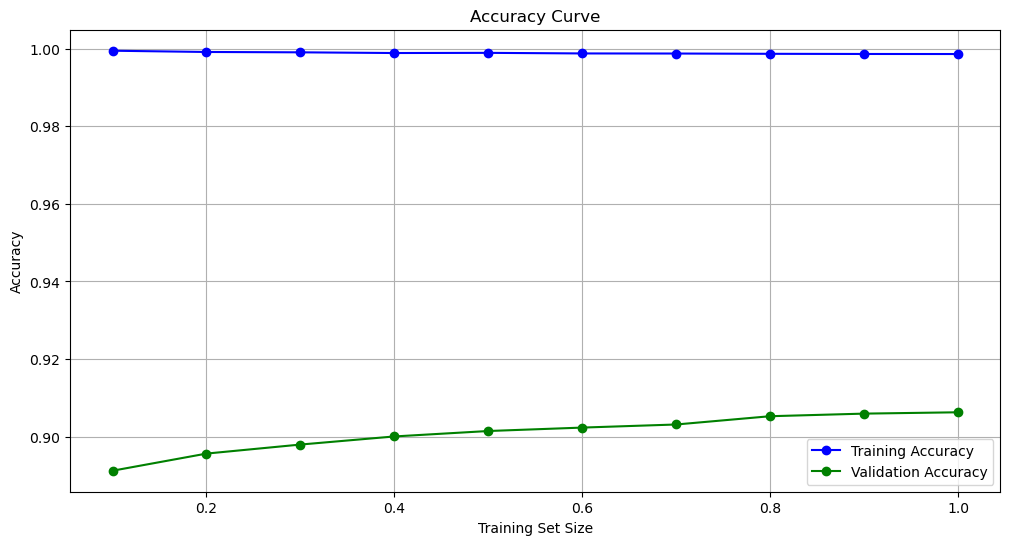

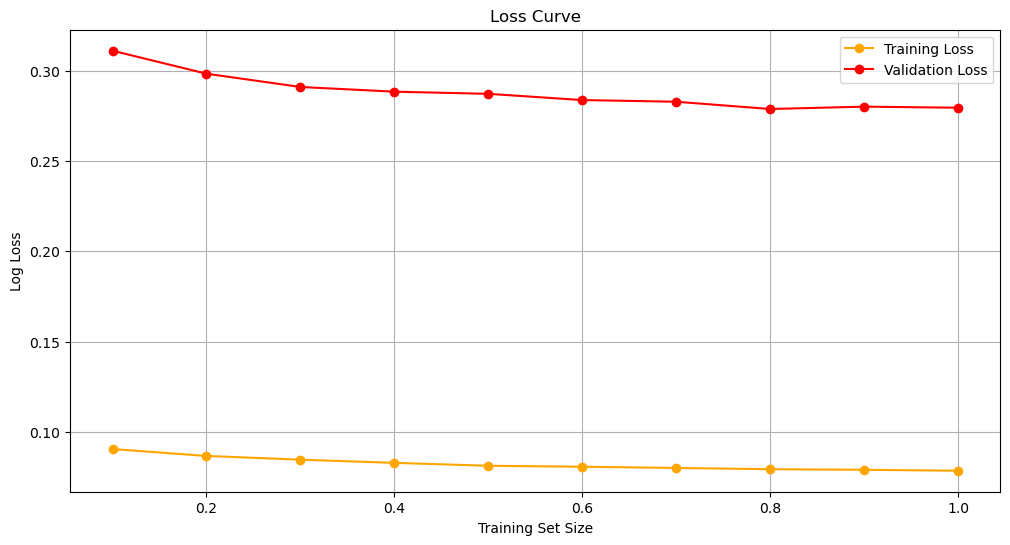

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import train_test_split

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Update with your actual file path
data = pd.read_excel(data_path)

# Define the column names for text and target labels
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Convert text data to numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Feature matrix
y = data[target_column]  # Target labels

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Arrays to store accuracy and loss
train_sizes = np.linspace(0.1, 1.0, 10)  # Progressively larger portions of the training data
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Loop through different training data sizes
for size in train_sizes:
    # Use a portion of the training data
    subset_size = int(size * X_train.shape[0])
    X_train_subset = X_train[:subset_size]
    y_train_subset = y_train[:subset_size]
    
    # Train the model on the subset
    rf_model.fit(X_train_subset, y_train_subset)
    
    # Predict on the training subset and validation set
    y_train_pred = rf_model.predict(X_train_subset)
    y_val_pred = rf_model.predict(X_test)
    
    # Predict probabilities for loss calculation
    y_train_proba = rf_model.predict_proba(X_train_subset)
    y_val_proba = rf_model.predict_proba(X_test)
    
    # Calculate accuracy
    train_accuracies.append(accuracy_score(y_train_subset, y_train_pred))
    val_accuracies.append(accuracy_score(y_test, y_val_pred))
    
    # Calculate log loss (Logarithmic Loss)
    train_losses.append(log_loss(y_train_subset, y_train_proba))
    val_losses.append(log_loss(y_test, y_val_proba))

# Plot Accuracy Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.title('Accuracy Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_losses, label='Training Loss', marker='o', color='orange')
plt.plot(train_sizes, val_losses, label='Validation Loss', marker='o', color='red')
plt.title('Loss Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend(loc='best')
plt.grid()
plt.show()
